# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [3]:
df_forniture =pd.read_csv(r"C:\Users\tifaw\OneDrive\Desktop\BOOTCAMP_DATASCIENCE\REPOSITORIO_GIT\ONLINE_DS_THEBRIDGE_FATIMA_NASSIRDINE\3-Machine_Learning\4-Series temporales\ejercicios\data\df_furniture.csv")

# Eliminamos filas que estén totalmente vacías (las que suelen estar al final del Excel/CSV)
df_forniture = df_forniture.dropna(how='all')
#NOta: en una serie temporal no podemos tener agujetos, la solucion es rellenar los datos que faltan.
#sacar un lista de la columna fecha entre el maximo y el minimo, rellenamos los valores.

In [4]:
df_forniture.head()

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


In [5]:
print(df_forniture.shape)
df_forniture.info()

(331, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     326 non-null    object 
 1   furniture_price_adjusted  331 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB


## 2. Tratar la fecha como texto e interpretar (parse)

In [6]:
# Limpieza de la columna 'Month' para evitar errores de espacios o tipos
df_forniture['Month'] = df_forniture['Month'].astype(str).str.strip()
print(df_forniture['Month'].dtype)
df_forniture.info() # sale como object porque pandas guarda las columans que son tipo 'str' como objetos

object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     331 non-null    object 
 1   furniture_price_adjusted  331 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB


In [7]:
# Creación de columnas'(Extracción desde la columna original 'Month')
df_forniture['year'] = df_forniture['Month'].str[:4]
df_forniture['month'] = df_forniture['Month'].str[5:7]
df_forniture['day'] = df_forniture['Month'].str[8:10]

# Creamos la columna'date' y conveetimos a datetime
# Usamos errors='coerce' por si acaso hay algún texto extraño; lo convertirá en NaT
df_forniture['date'] = pd.to_datetime(df_forniture[['year', 'month', 'day']], errors='coerce')

# Eliminamos posible existencia de valores Nat para que no llegen al índice
df_forniture = df_forniture.dropna(subset=['date'])  # Elimina filas donde la columna 'date' tiene valores nulos

# Establecemos como índice (fundamental para series temporales)
df_forniture.set_index('date', inplace=True)

# Ordenar por fecha (muy importante en series temporales)
df_forniture.sort_index(inplace=True)

# Comprobación final
print("¿Hay nulos en el índice?:", df_forniture.index.hasnans)
df_forniture.head()




¿Hay nulos en el índice?: False


,Month,furniture_price_adjusted,year,month,day
date,,,,,
1992-01-01,1992-01-01,2073.432724,1992,01,01
1992-02-01,1992-02-01,2114.485812,1992,02,01
1992-03-01,1992-03-01,2260.570891,1992,03,01
1992-04-01,1992-04-01,2255.103236,1992,04,01
1992-05-01,1992-05-01,2331.414618,1992,05,01


## 3. ¿De qué fecha a qué fecha va el histórico?

In [8]:
df_forniture.index # 

DatetimeIndex(['1992-01-01', '1992-02-01', '1992-03-01', '1992-04-01',
               '1992-05-01', '1992-06-01', '1992-07-01', '1992-08-01',
               '1992-09-01', '1992-10-01',
               ...
               '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01',
               '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01',
               '2019-06-01', '2019-07-01'],
              dtype='datetime64[ns]', name='date', length=326, freq=None)

## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

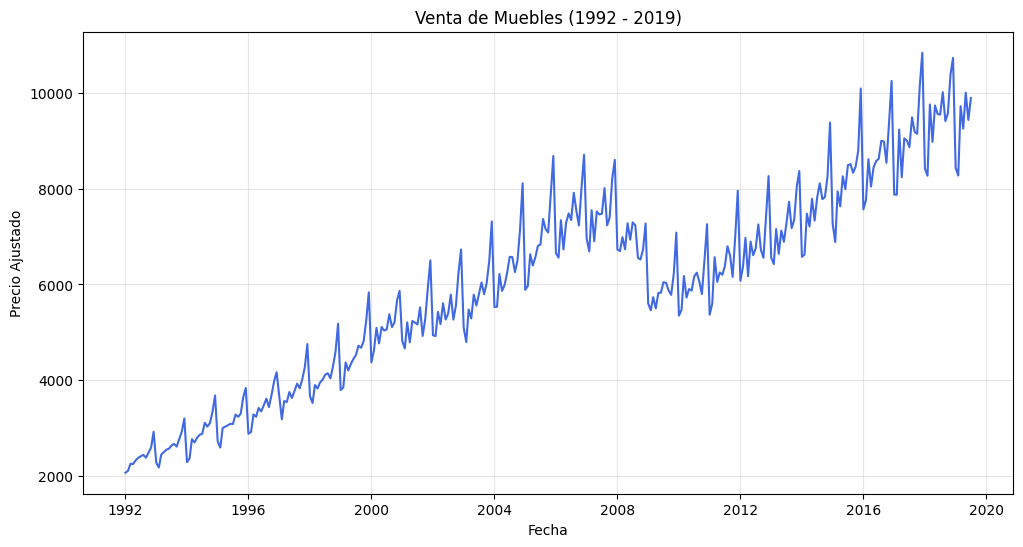

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df_forniture['furniture_price_adjusted'], color='royalblue')
plt.title('Venta de Muebles (1992 - 2019)')
plt.xlabel('Fecha')
plt.ylabel('Precio Ajustado')
plt.grid(True, alpha=0.3)
plt.show()

# Respuesta teórica:
# 1. Tendencia: Sí, se observa una clara tendencia alcista a lo largo de los años.
# 2. Estacionalidad: Sí, se aprecian patrones cíclicos (picos y valles) que se repiten anualmente.

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

Opción uno.
nota: Una serie es estacionaria si su media y varianza son constantes en el tiempo. 
se parte la serie temporal en 3 cachos se saca la media y varianza y si es la misma en lso 3 tramos, la serie es estacionaria.

In [ ]:
#Opcion dos.
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_forniture['furniture_price_adjusted'].values)

result[1] # nose como interpreto esto, he hecho un copia pega de lo que sale en los apuntes
#Entinddo que es el p-.valor 0.71, la serie no es estacionaria, el p-valor es mayor a 0.05 


np.float64(0.7171679263890343)

## 6. ¿Conoces algún método para representar mejor la tendencia?

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Media móvil
result_add = seasonal_decompose(
    df_forniture['furniture_price_adjusted'],
    model='additive',
    period=12
)


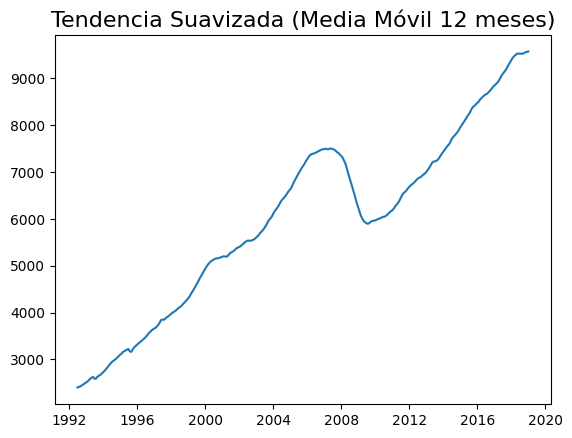

In [12]:
plt.plot(result_add.trend) #con esto sacamos la tendencia
plt.title('Tendencia Suavizada (Media Móvil 12 meses)', fontsize=16);

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

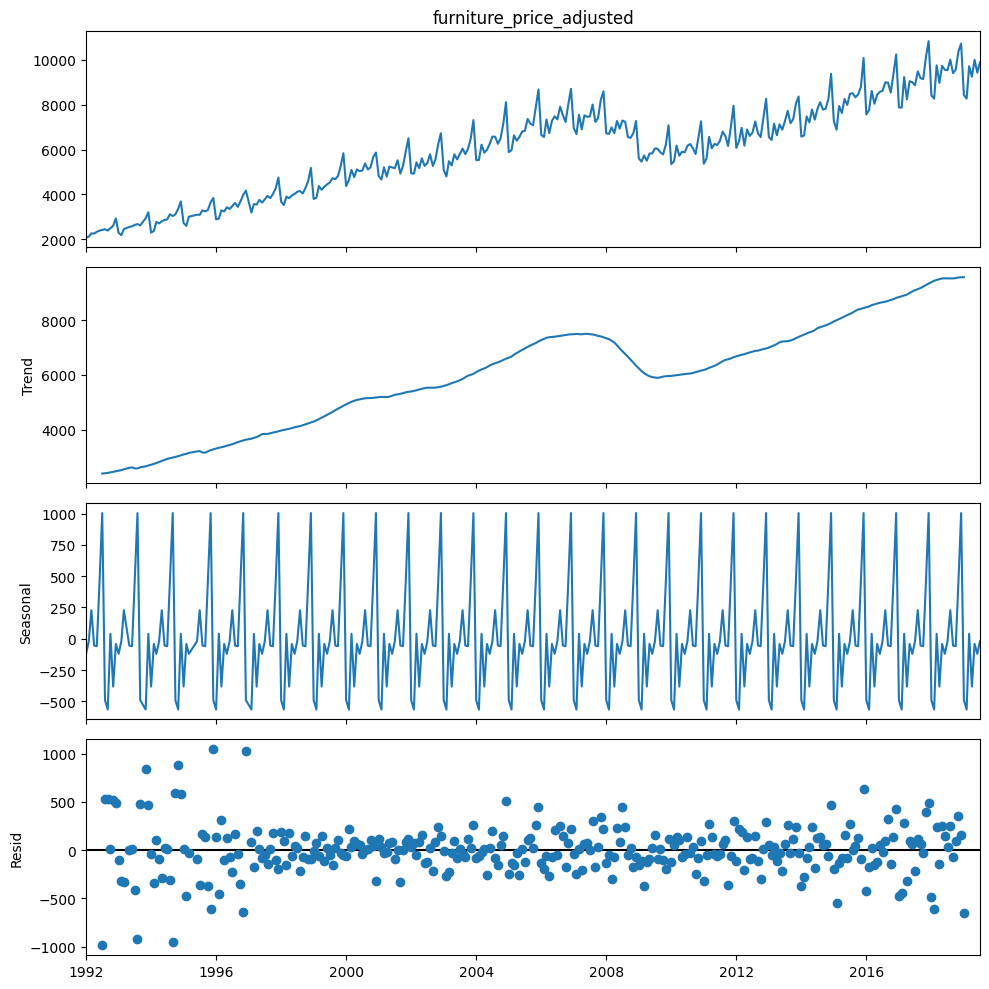

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Realizamos la descomposición (periodo 12 porque son meses)
descomposicion = seasonal_decompose(df_forniture['furniture_price_adjusted'], 
                                   model='additive', 
                                   period=12)

# 2. Graficamos todos los componentes
plt.rcParams.update({'figure.figsize': (10,10)})
descomposicion.plot()
plt.show()

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

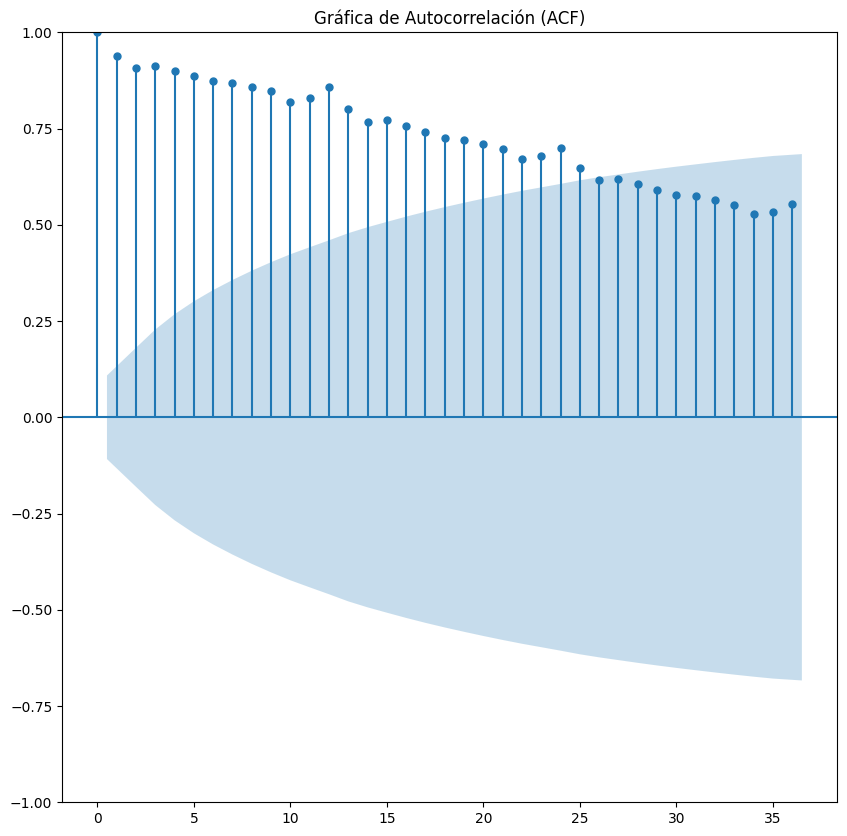

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

# Graficamos la autocorrelación para 36 meses (3 años)
plot_acf(df_forniture['furniture_price_adjusted'], lags=36)
plt.title('Gráfica de Autocorrelación (ACF)')
plt.show()

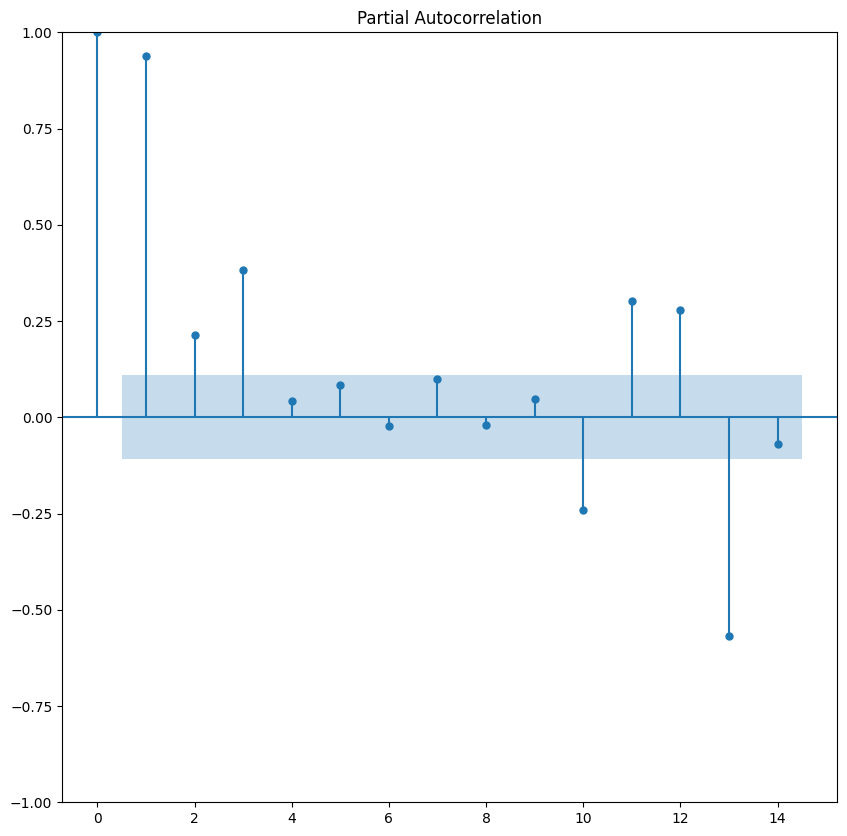

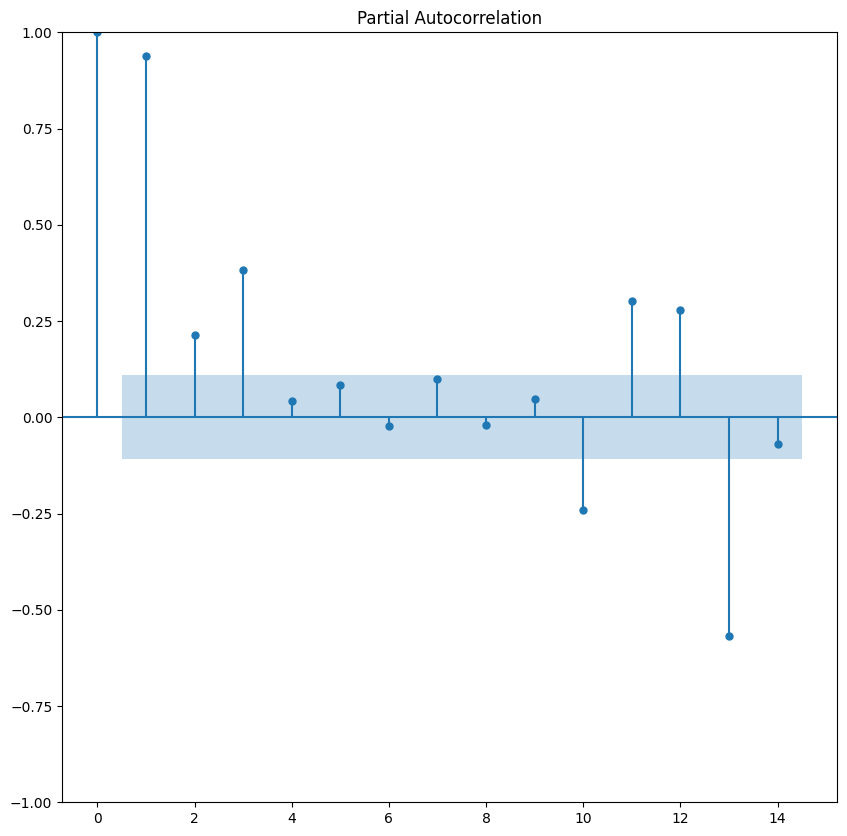

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_forniture[['furniture_price_adjusted']].values, lags= 14)

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

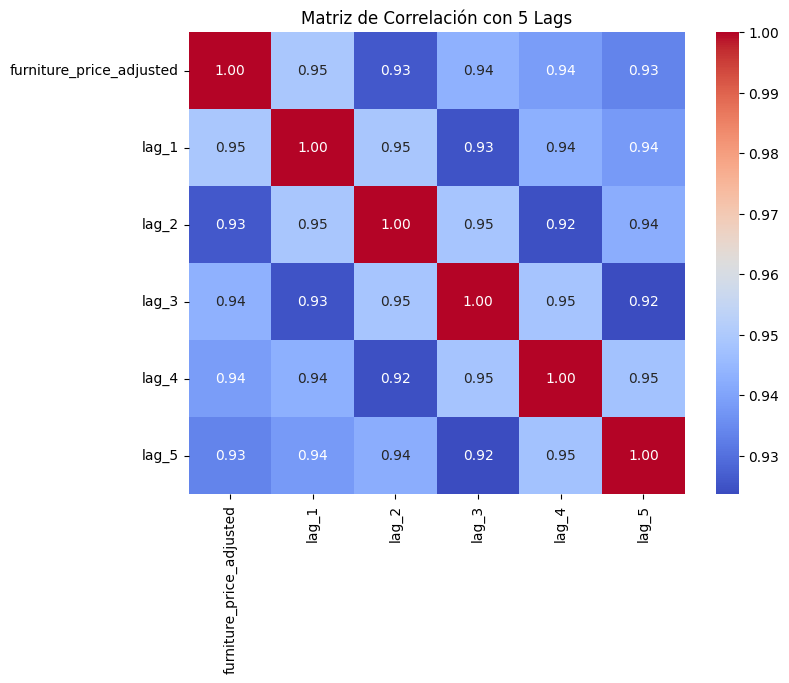

In [15]:
# Creamos las columnas de 'retraso' (lags)
df_lags = pd.DataFrame(df_forniture['furniture_price_adjusted'])

for i in range(1, 6):
    df_lags[f'lag_{i}'] = df_lags['furniture_price_adjusted'].shift(i)

# Matriz de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df_lags.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación con 5 Lags')
plt.show()

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

In [16]:
#Mirando la gráfica de descomposicion o la de ACF, vemos que el patrón se repite cada 12 instantes (12 meses = 1 año)

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

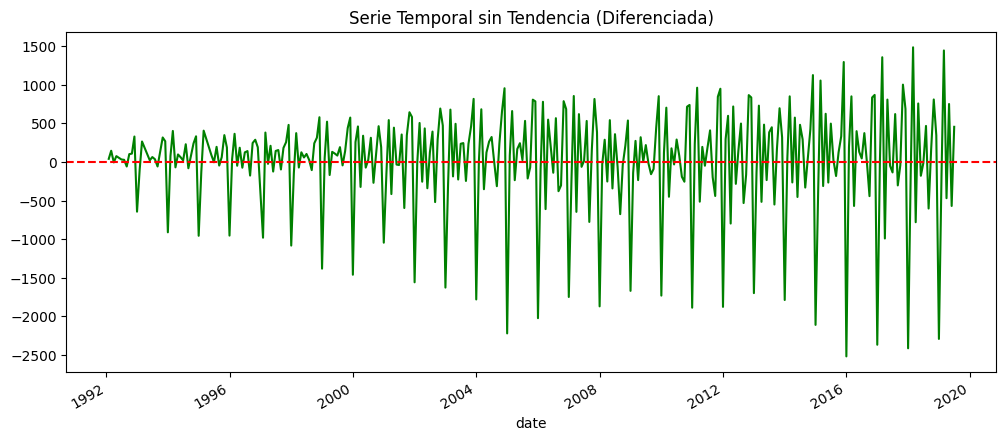

In [17]:
# Restamos el valor actual menos el del mes anterior
df_forniture['desestacionalizada'] = df_forniture['furniture_price_adjusted'].diff()

# Graficamos el resultado
df_forniture['desestacionalizada'].plot(figsize=(12, 5), color='green')
plt.title('Serie Temporal sin Tendencia (Diferenciada)')
plt.axhline(y=0, color='red', linestyle='--') # Línea base en cero
plt.show()